Shape: (3461, 64)
Num departments: 94
Years: [1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995
 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009
 2010 2011 2012 2013 2014 2015 2016 2017 2018]
After lagging shape: (3367, 65)
Years used: [1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996
 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010
 2011 2012 2013 2014 2015 2016 2017 2018]
Num features: 58
X shape: (3367, 58)
Lag cols: ['yield_lag1']
Num climate cols: 57

==== Rolling CV: Lags only ====
Year 1984: R2=-0.603, RMSE=1.653, MAE=1.479
Year 1985: R2=0.459, RMSE=0.838, MAE=0.685
Year 1986: R2=0.631, RMSE=0.878, MAE=0.674
Year 1987: R2=0.492, RMSE=0.823, MAE=0.684
Year 1988: R2=0.664, RMSE=0.755, MAE=0.637
Year 1989: R2=0.666, RMSE=0.736, MAE=0.580
Year 1990: R2=0.775, RMSE=0.626, MAE=0.519
Year 1991: R2=0.602, RMSE=0.886, MAE=0.753
Year 1992: R2=0.763, RMSE=0.559, MAE=0.470
Year 1993: R2=0.705, RMSE=0.557, M

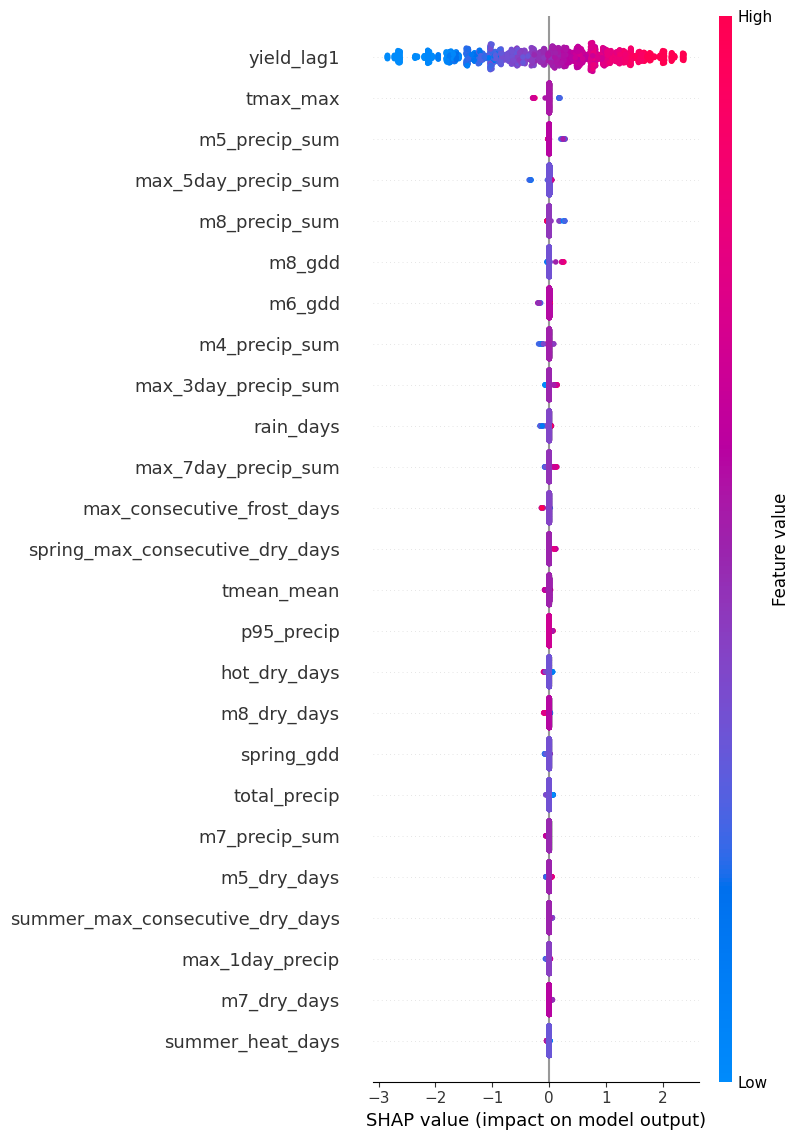


Top climate variables by SHAP:
tmax_max                           0.002453
m5_precip_sum                      0.002379
max_5day_precip_sum                0.002185
m8_precip_sum                      0.002072
m8_gdd                             0.001621
m6_gdd                             0.001591
m4_precip_sum                      0.001222
max_3day_precip_sum                0.001148
rain_days                          0.001124
max_7day_precip_sum                0.001043
max_consecutive_frost_days         0.000998
spring_max_consecutive_dry_days    0.000919
tmean_mean                         0.000917
p95_precip                         0.000807
hot_dry_days                       0.000761
m8_dry_days                        0.000721
spring_gdd                         0.000678
total_precip                       0.000603
m7_precip_sum                      0.000551
m5_dry_days                        0.000514
dtype: float32


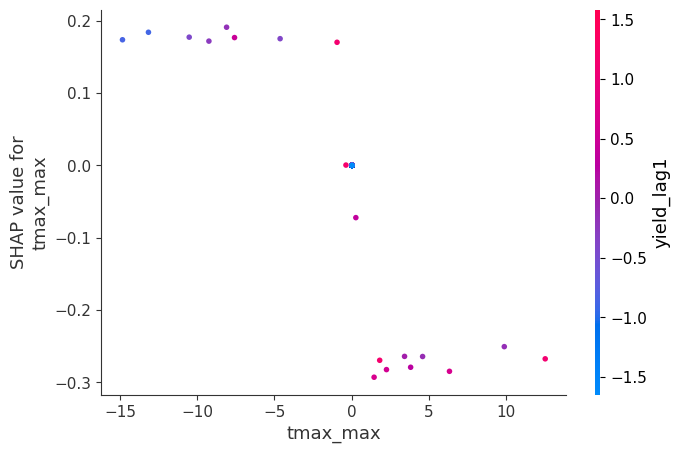

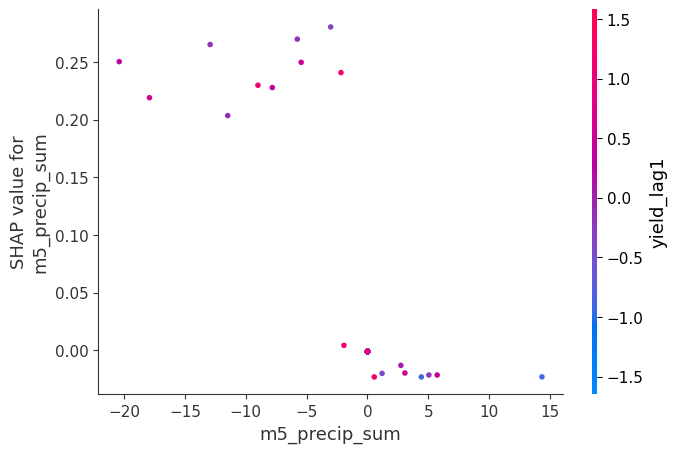

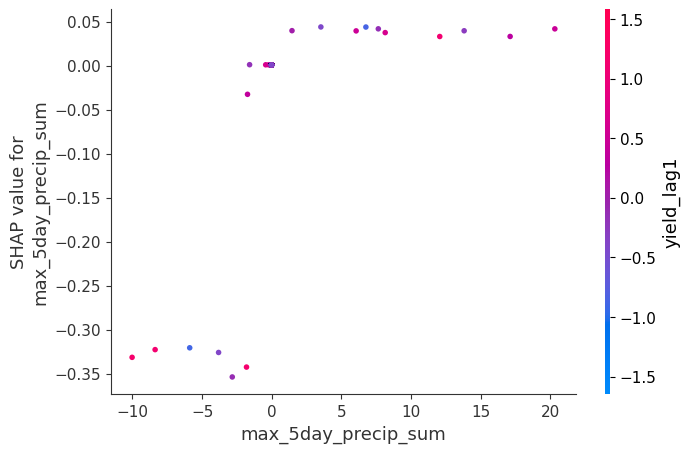

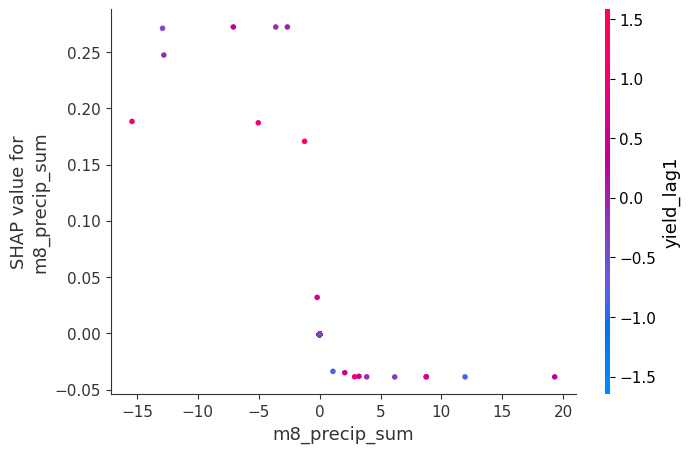

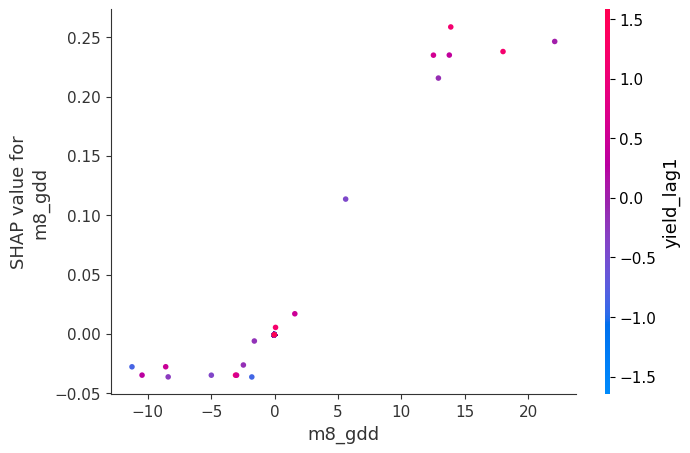

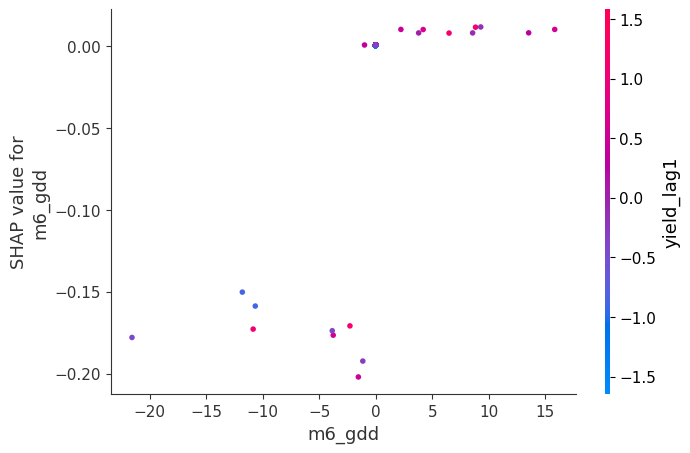


Done ✅ Modelling + SHAP complete.


In [123]:
import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# =========================
# 1) Load processed data
# =========================
DATA_PATH = "../data/processed/barley_climate_model_ready.csv"
df = pd.read_csv(DATA_PATH)

# Sort panel
df = df.sort_values(["department", "year"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Num departments:", df["department"].nunique())
print("Years:", np.sort(df["year"].unique()))

# =========================
# 2) Choose TARGET
# =========================
TARGET = "yield"   # try also "yield_detrended" later

# =========================
# 3) Create lag1 per department
# =========================
df[f"{TARGET}_lag1"] = df.groupby("department")[TARGET].shift(1)

df_model = df.dropna().reset_index(drop=True)

print("After lagging shape:", df_model.shape)
print("Years used:", np.sort(df_model["year"].unique()))

# =========================
# 4) Build feature matrix
# =========================
LEAKAGE_COLS = ["yield", "yield_detrended", "production", "area"]

DROP_COLS = ["year", "code_dep"] + LEAKAGE_COLS

FEATURE_COLS = [c for c in df_model.columns if c not in DROP_COLS and c != "department"]

X = df_model[FEATURE_COLS].copy()
y = df_model[TARGET].copy()

print("Num features:", len(FEATURE_COLS))
print("X shape:", X.shape)

# =========================
# 5) Scale features
# =========================
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split lag vs climate
lag_cols = [c for c in X_scaled.columns if c == f"{TARGET}_lag1"]
climate_cols = [c for c in X_scaled.columns if c not in lag_cols]

print("Lag cols:", lag_cols)
print("Num climate cols:", len(climate_cols))

years = df_model["year"].values

# =========================
# 6) Rolling-year CV function
# =========================
def rolling_year_cv(years):
    uniq = np.sort(np.unique(years))
    for y in uniq[1:]:
        train_idx = np.where(years < y)[0]
        test_idx = np.where(years == y)[0]
        if len(train_idx) > 0 and len(test_idx) > 0:
            yield train_idx, test_idx, y

# =========================
# 7) Compare three models
# =========================
def eval_model(Xmat, y, years, name):
    r2s, rmses, maes = [], [], []
    print(f"\n==== Rolling CV: {name} ====")

    for train_idx, test_idx, y_test_year in rolling_year_cv(years):
        X_train, X_test = Xmat.iloc[train_idx], Xmat.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = xgb.XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            min_child_weight=10,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=2.0,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)

        print(f"Year {y_test_year}: R2={r2:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}")

        r2s.append(r2)
        rmses.append(rmse)
        maes.append(mae)

    print(f"\n{name} summary:")
    print("R2 mean:", np.mean(r2s))
    print("RMSE mean:", np.mean(rmses))
    print("MAE mean:", np.mean(maes))

    return np.mean(r2s), np.mean(rmses), np.mean(maes)

# ---- Lags only
X_lag = X_scaled[lag_cols]
r2_lag, rmse_lag, mae_lag = eval_model(X_lag, y, years, "Lags only")

# ---- Climate only
X_clim = X_scaled[climate_cols]
r2_clim, rmse_clim, mae_clim = eval_model(X_clim, y, years, "Climate only")

# ---- Lags + Climate
X_full = X_scaled
r2_full, rmse_full, mae_full = eval_model(X_full, y, years, "Lags + Climate")

print("\n==== Model comparison ====")
print("Lags only R2:", r2_lag)
print("Climate only R2:", r2_clim)
print("Lags + Climate R2:", r2_full)

# =========================
# 8) Train final model on full data (Lags + Climate)
# =========================
final_model = xgb.XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_full, y)

# =========================
# 9) SHAP interpretation (focus on climate)
# =========================
# Sample for speed
X_shap = X_full.sample(min(2000, len(X_full)), random_state=42)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

# Global importance
shap.summary_plot(shap_values, X_shap, max_display=25)

# Climate-only SHAP ranking
clim_shap = pd.Series(
    np.abs(shap_values[:, [X_full.columns.get_loc(c) for c in climate_cols]]).mean(axis=0),
    index=climate_cols
).sort_values(ascending=False)

print("\nTop climate variables by SHAP:")
print(clim_shap.head(20))

# Dependence plots for top 6 climate variables
top6 = clim_shap.head(6).index.tolist()
for v in top6:
    shap.dependence_plot(v, shap_values, X_shap)

print("\nDone ✅ Modelling + SHAP complete.")



Typology counts:
typology
HighYield-HighArea    36
LowYield-LowArea      36
HighYield-LowArea     11
LowYield-HighArea     11
Name: count, dtype: int64

Trend slope distribution:
count    94.000000
mean      0.045503
std       0.020007
min      -0.004457
25%       0.031707
50%       0.046701
75%       0.057353
max       0.093089
Name: yield_trend_slope, dtype: float64

Trend quantile thresholds:
Slow/Fast cutoffs: 0.031706812470365095 0.05735335507430526

Growth class counts:
growth_class
MediumGrowth    46
FastGrowth      24
SlowGrowth      24
Name: count, dtype: int64

Flag counts:
Intervene: 3
Protect: 36
Scale-up: 4
Deprioritise: 13

Top intervention candidates:


,department,mean_yield,mean_area,mean_production,n_years,typology,yield_trend_slope,n_years_trend,growth_class,flag_intervene,flag_protect,flag_scale_up,flag_deprioritise
36,Haute_Garonne,4.647711,14938.972973,68856.909459,37,LowYield-HighArea,0.012538,37,SlowGrowth,True,False,False,False
82,Tarn,4.605080,21909.567568,100288.477027,37,LowYield-HighArea,0.022847,37,SlowGrowth,True,False,False,False
32,Gers,4.635888,19864.702703,90268.743243,37,LowYield-HighArea,0.023825,37,SlowGrowth,True,False,False,False



Top scale-up candidates:


,department,mean_yield,mean_area,mean_production,n_years,typology,yield_trend_slope,n_years_trend,growth_class,flag_intervene,flag_protect,flag_scale_up,flag_deprioritise
84,Territoire_de_Belfort,5.384801,1067.783784,5427.110811,37,HighYield-LowArea,0.077500,37,FastGrowth,False,False,True,False
0,Ain,5.416341,10065.000000,52637.545946,37,HighYield-LowArea,0.070712,37,FastGrowth,False,False,True,False
34,Haut_Rhin,5.607777,3960.514286,20092.422857,35,HighYield-LowArea,0.057645,35,FastGrowth,False,False,True,False
59,Manche,5.552226,6248.837838,35177.664865,37,HighYield-LowArea,0.057575,37,FastGrowth,False,False,True,False


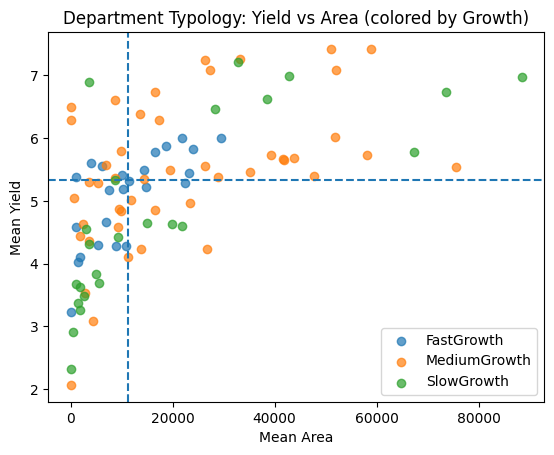

In [127]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# =========================
# 0) Safety checks
# =========================
assert {"department", "year", "yield", "area", "production"}.issubset(df.columns)

# =========================
# 1) Long-run averages per department (Yield × Area)
# =========================
dept_stats = (
    df.groupby("department")
      .agg(
          mean_yield=("yield", "mean"),
          mean_area=("area", "mean"),
          mean_production=("production", "mean"),
          n_years=("year", "count")
      )
      .reset_index()
)

# Median splits
yield_thresh = dept_stats["mean_yield"].median()
area_thresh  = dept_stats["mean_area"].median()

def classify_typology(row):
    if row["mean_yield"] >= yield_thresh and row["mean_area"] >= area_thresh:
        return "HighYield-HighArea"
    elif row["mean_yield"] >= yield_thresh and row["mean_area"] < area_thresh:
        return "HighYield-LowArea"
    elif row["mean_yield"] < yield_thresh and row["mean_area"] >= area_thresh:
        return "LowYield-HighArea"
    else:
        return "LowYield-LowArea"

dept_stats["typology"] = dept_stats.apply(classify_typology, axis=1)

print("\nTypology counts:")
print(dept_stats["typology"].value_counts())

# =========================
# 2) Yield trend slopes per department
# =========================
trend_rows = []

for dep, g in df.groupby("department"):
    g = g.sort_values("year")
    if len(g) < 8:
        continue

    X_year = g["year"].values.reshape(-1, 1)
    y_yield = g["yield"].values

    lr = LinearRegression()
    lr.fit(X_year, y_yield)

    slope = lr.coef_[0]

    trend_rows.append({
        "department": dep,
        "yield_trend_slope": slope,
        "n_years_trend": len(g)
    })

trend_df = pd.DataFrame(trend_rows)

print("\nTrend slope distribution:")
print(trend_df["yield_trend_slope"].describe())

# =========================
# 3) Classify relative growth (quantiles)
# =========================
q_low  = trend_df["yield_trend_slope"].quantile(0.25)
q_high = trend_df["yield_trend_slope"].quantile(0.75)

print("\nTrend quantile thresholds:")
print("Slow/Fast cutoffs:", q_low, q_high)

def classify_growth(s):
    if s <= q_low:
        return "SlowGrowth"
    elif s >= q_high:
        return "FastGrowth"
    else:
        return "MediumGrowth"

trend_df["growth_class"] = trend_df["yield_trend_slope"].apply(classify_growth)

print("\nGrowth class counts:")
print(trend_df["growth_class"].value_counts())

# =========================
# 4) Merge Typology + Trend
# =========================
dept_strategy = dept_stats.merge(trend_df, on="department", how="left")

# =========================
# 5) Policy flags
# =========================

# High priority intervention: big area, low yield, slow growth
dept_strategy["flag_intervene"] = (
    (dept_strategy["typology"] == "LowYield-HighArea") &
    (dept_strategy["growth_class"] == "SlowGrowth")
)

# Protect & intensify: big area, high yield
dept_strategy["flag_protect"] = (
    dept_strategy["typology"] == "HighYield-HighArea"
)

# Scale-up candidates: small area, high yield, fast growth
dept_strategy["flag_scale_up"] = (
    (dept_strategy["typology"] == "HighYield-LowArea") &
    (dept_strategy["growth_class"] == "FastGrowth")
)

# Deprioritise: small area, low yield, slow growth
dept_strategy["flag_deprioritise"] = (
    (dept_strategy["typology"] == "LowYield-LowArea") &
    (dept_strategy["growth_class"] == "SlowGrowth")
)

print("\nFlag counts:")
print("Intervene:", dept_strategy["flag_intervene"].sum())
print("Protect:", dept_strategy["flag_protect"].sum())
print("Scale-up:", dept_strategy["flag_scale_up"].sum())
print("Deprioritise:", dept_strategy["flag_deprioritise"].sum())

# =========================
# 6) Quick inspection tables
# =========================

print("\nTop intervention candidates:")
display(
    dept_strategy[dept_strategy["flag_intervene"]]
    .sort_values("yield_trend_slope")
    .head(10)
)

print("\nTop scale-up candidates:")
display(
    dept_strategy[dept_strategy["flag_scale_up"]]
    .sort_values("yield_trend_slope", ascending=False)
    .head(10)
)

# =========================
# 7) Simple strategy plot: Yield vs Area, colored by Growth
# =========================

plt.figure()
for cls, sub in dept_strategy.groupby("growth_class"):
    plt.scatter(sub["mean_area"], sub["mean_yield"], label=cls, alpha=0.7)

plt.axhline(yield_thresh, linestyle="--")
plt.axvline(area_thresh, linestyle="--")

plt.xlabel("Mean Area")
plt.ylabel("Mean Yield")
plt.title("Department Typology: Yield vs Area (colored by Growth)")
plt.legend()
plt.show()

